<a href="https://colab.research.google.com/github/salsilsulselsol/Associate-Data-Scientist-Python-Nasional-Notes-Experiment/blob/main/practice_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-Practice: Data Understanding & Validation
**Dataset:** Data_Nasabah.csv

**Source:** https://github.com/syncora-ai/credit-scoring-dataset-/blob/main/synthetic_e2dabba50a1a4fbcabd601f7883eef1e.csv

**Objective:** Perform a comprehensive data audit and exploration following the CRISP-DM framework.

This notebook covers:
1. Data Description (Structural Inspection)
2. Data Exploration (Visual Analysis)
3. Data Quality Verification (Validation)

## Stage 1: Describing Data

In [2]:
import pandas as pd

# Load the dataset
# Ensure your file is named 'Data_Nasabah.csv' in the Colab environment
file_path = 'Data_Nasabah.csv'
data = pd.read_csv(file_path)

In [3]:
# 1.1 Data Dimensions
print(f"Dataset Dimensions: {data.shape[0]} rows, {data.shape[1]} columns")

Dataset Dimensions: 4995 rows, 87 columns


In [4]:
# 1.2 Technical Metadata
print("\n--- Technical Metadata (Info) ---")
print(data.info())


--- Technical Metadata (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 87 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  4995 non-null   object 
 1   INCOME                   4995 non-null   int64  
 2   SAVINGS                  4995 non-null   int64  
 3   DEBT                     4995 non-null   int64  
 4   R_SAVINGS_INCOME         4995 non-null   float64
 5   R_DEBT_INCOME            4995 non-null   float64
 6   R_DEBT_SAVINGS           4995 non-null   float64
 7   T_CLOTHING_12            4995 non-null   int64  
 8   T_CLOTHING_6             4995 non-null   int64  
 9   R_CLOTHING               4995 non-null   float64
 10  R_CLOTHING_INCOME        4995 non-null   float64
 11  R_CLOTHING_SAVINGS       4995 non-null   float64
 12  R_CLOTHING_DEBT          4995 non-null   float64
 13  T_EDUCATION_12           4995 non-null   in

In [5]:
# 1.3 Statistical Summary
print("\n--- Descriptive Statistics (Numeric) ---")
print(data.describe())


--- Descriptive Statistics (Numeric) ---
              INCOME       SAVINGS          DEBT  R_SAVINGS_INCOME  \
count    4995.000000  4.995000e+03  4.995000e+03       4995.000000   
mean   112030.816016  4.184128e+05  7.200020e+05          4.489922   
std    121991.815056  4.384830e+05  9.975662e+05          4.382761   
min         0.000000  0.000000e+00  0.000000e+00          0.000000   
25%      8950.500000  7.575250e+04  1.998050e+04          0.980800   
50%     61229.000000  2.891120e+05  2.271580e+05          2.977400   
75%    191468.000000  6.234835e+05  1.095794e+06          6.799900   
max    662094.000000  2.911863e+06  5.968620e+06         16.111200   

       R_DEBT_INCOME  R_DEBT_SAVINGS  T_CLOTHING_12  T_CLOTHING_6  \
count    4995.000000     4995.000000    4995.000000   4995.000000   
mean        6.176271        6.731365    7336.379580   3252.797998   
std         4.924046       14.994629    7483.619666   5182.946091   
min         0.083300        0.006800       0.000000

In [6]:
# 1.4 Unique Value Identification (Sampling first 20 columns for brevity)
print("\n--- Unique Values Count ---")
for column in data.columns[:20]:
    print(f"{column}: {data[column].nunique()} unique values")


--- Unique Values Count ---
CUST_ID: 4995 unique values
INCOME: 4687 unique values
SAVINGS: 4921 unique values
DEBT: 4775 unique values
R_SAVINGS_INCOME: 4720 unique values
R_DEBT_INCOME: 4894 unique values
R_DEBT_SAVINGS: 4631 unique values
T_CLOTHING_12: 4092 unique values
T_CLOTHING_6: 2887 unique values
R_CLOTHING: 3824 unique values
R_CLOTHING_INCOME: 1354 unique values
R_CLOTHING_SAVINGS: 1290 unique values
R_CLOTHING_DEBT: 937 unique values
T_EDUCATION_12: 3991 unique values
T_EDUCATION_6: 3569 unique values
R_EDUCATION: 121 unique values
R_EDUCATION_INCOME: 2224 unique values
R_EDUCATION_SAVINGS: 2211 unique values
R_EDUCATION_DEBT: 789 unique values
T_ENTERTAINMENT_12: 4370 unique values


In [7]:
# 1.5 Schema Encoding (Example on CAT_GAMBLING)
if 'CAT_GAMBLING' in data.columns:
    print("\nEncoding 'CAT_GAMBLING' to Numeric...")
    data['CAT_GAMBLING_CODE'] = data['CAT_GAMBLING'].map({'No': 0, 'Low': 1, 'Medium': 2, 'High': 3})
    print(data[['CUST_ID', 'CAT_GAMBLING', 'CAT_GAMBLING_CODE']].head())


Encoding 'CAT_GAMBLING' to Numeric...
         CUST_ID CAT_GAMBLING  CAT_GAMBLING_CODE
0  sdv-id-AWJoYv         High                  3
1  sdv-id-MqZrHS           No                  0
2  sdv-id-Evqdpj         High                  3
3  sdv-id-CHnYOs           No                  0
4  sdv-id-ByqsvL           No                  0


## Stage 2: Exploratory Data Analysis (EDA)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

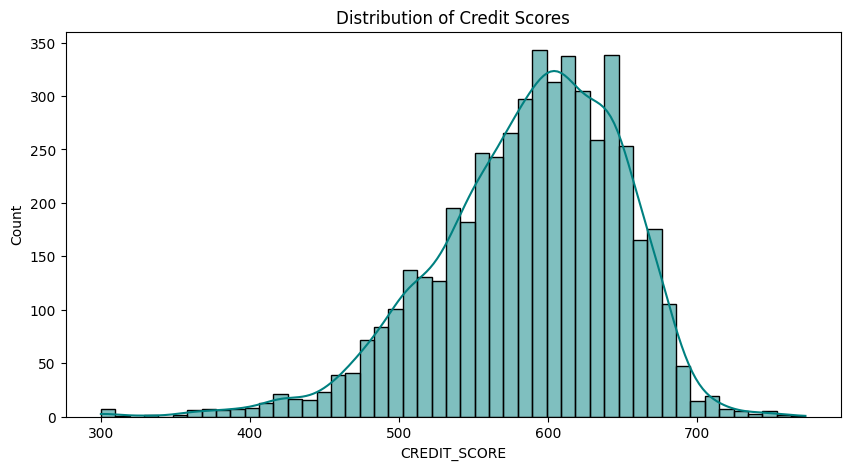

In [9]:
# 2.1 Numerical Distribution (Credit Score)
plt.figure(figsize=(10, 5))
sns.histplot(data['CREDIT_SCORE'], kde=True, color='teal')
plt.title("Distribution of Credit Scores")
plt.show()

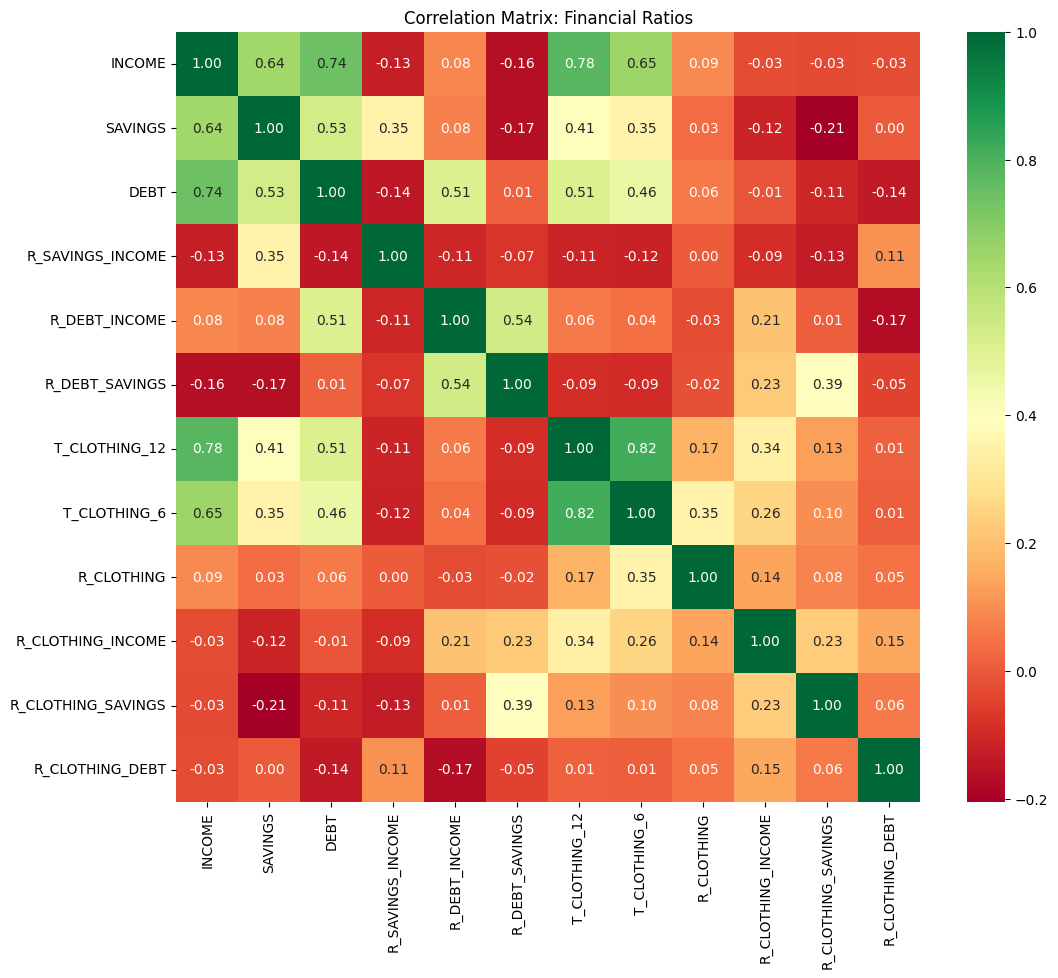

In [10]:
# 2.2 Correlation Analysis
# Analyzing the first 12 financial attributes
plt.figure(figsize=(12, 10))
correlation_matrix = data.iloc[:, 1:13].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Matrix: Financial Ratios")
plt.show()

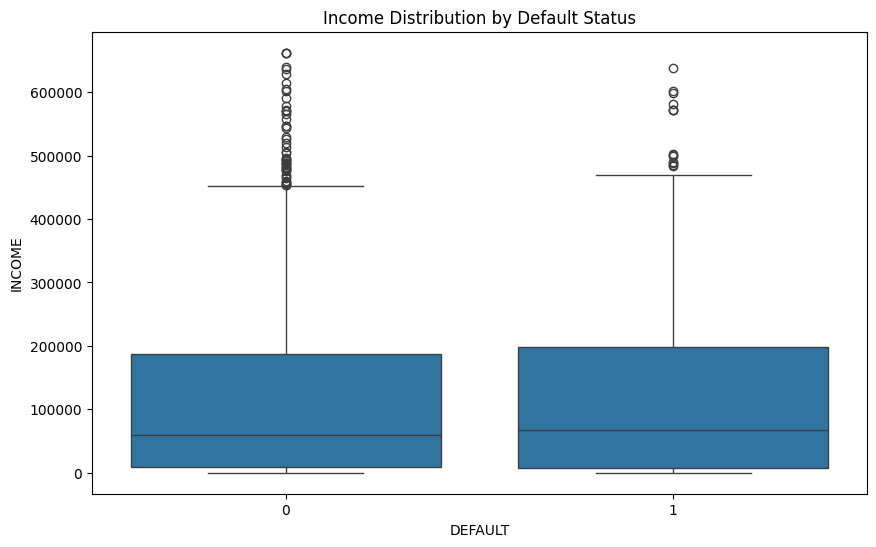

In [11]:
# 2.3 Categorical Analysis (Default Status vs Income)
plt.figure(figsize=(10, 6))
sns.boxplot(x='DEFAULT', y='INCOME', data=data)
plt.title("Income Distribution by Default Status")
plt.show()

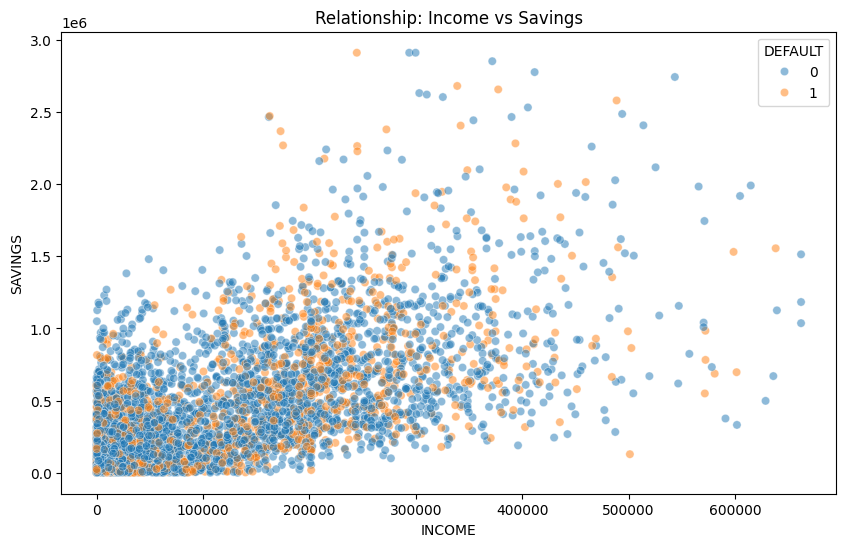

In [12]:
# 2.4 Bivariate Analysis (Income vs Savings)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='INCOME', y='SAVINGS', hue='DEFAULT', data=data, alpha=0.5)
plt.title("Relationship: Income vs Savings")
plt.show()

## Stage 3: Verifying Data Quality

In [13]:
print("--- Data Quality Audit ---")

# 3.1 Missing Value Detection
missing_values = data.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

# 3.2 Duplicate Record Detection
duplicates = data.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

# 3.3 Logical Consistency Checks
# Checking for negative values in columns that should be positive
negative_income = data[data['INCOME'] < 0].shape[0]
negative_debt = data[data['DEBT'] < 0].shape[0]

print(f"Invalid Records (Negative Income): {negative_income}")
print(f"Invalid Records (Negative Debt): {negative_debt}")

# 3.4 Outlier Check (Credit Score range validation 300-850)
invalid_scores = data[(data['CREDIT_SCORE'] < 300) | (data['CREDIT_SCORE'] > 850)].shape[0]
print(f"Outlier Credit Scores Detected: {invalid_scores}")

--- Data Quality Audit ---
Total Missing Values: 0
Total Duplicate Rows: 0
Invalid Records (Negative Income): 0
Invalid Records (Negative Debt): 0
Outlier Credit Scores Detected: 0


## Documentation of Practice Results

### 1. Data Summary
* The dataset consists of 4,995 entries and 87 attributes.
* Most features are numerical (floats and integers), representing financial ratios and expenditures.

### 2. Significant Findings
* **Correlation**: High correlation identified between income levels and specific spending categories.
* **Target Insight**: There is a visible separation in credit scores between defaulting and non-defaulting customers.

### 3. Data Integrity
* **Completeness**: No missing values were found in the current dataset.
* **Consistency**: No negative financial values or logical outliers were detected in core metrics.

### 4. Recommendations
* Proceed to **Data Preparation** phase for feature selection, as 87 columns may contain redundant information.
* Standardize financial columns (Income, Savings) to ensure model stability.